In [57]:
import os

import numpy as np
import pandas as pd

from scipy.stats import linregress

import matplotlib.pyplot as plt

In [10]:
df_n1 = pd.read_excel("./data/mCALR N-1.xlsx", header = 1)
df_n1 = df_n1[2:].reset_index(drop = True)
df_n1.columns = ["Batch"] + df_n1.columns[1:].tolist()
df_n1.drop(["Variable"], axis = 1, inplace = True)
df_n1

,Batch,Generic.Bioreactor.End Culture.Culture duration,Generic.Bioreactor.Equipment parameters at inoculation.Air sparger,Generic.Bioreactor.Equipment parameters at inoculation.pH primary probe,Generic.Bioreactor.Pre-Inoculation.pCO2,Generic.Bioreactor.Pre-Inoculation.pH,Generic.Bioreactor.Pre-Inoculation.pO2,0.8X HIP MEDIUM,1M Sodium Carbonate Solution,CAMPAIGN,Glucose 500 g/L,OPTICHO GROWTH MEDIUM
0,FA001,168,2.504,6.8,12.1,7.679,135.3,1003039.0,1003086.0,FA001,1003060.0,1003077.0
1,FA002,170,2.504,6.79,31.7,7.437,117.9,1003133.0,1002709.0,FA002,1003060.0,1003210.0
2,FA003,168,2.004,6.8,10,7.85,135.6,1003240.0,1003086.0,FA003,1003060.0,1003310.0
3,FA004,170,2.004,6.8,10,7.875,145.9,1004007.0,1003814.0,FA004,1003732.0,1004091.0
4,FA005,167,2.004,6.81,10,7.783,140.7,1004087.0,1003814.0,FA005,1003732.0,1004151.0
5,FA006,168,2.004,6.81,10.6,7.76,139.4,1004164.0,1004090.0,FA006,1003732.0,1004329.0
6,FA007,168,2.004,6.8,10,7.787,135.7,1004328.0,1004090.0,FA007,1004089.0,1004369.0
7,FA008,171,2.004,6.82,10,7.776,138.5,1004384.0,1004090.0,FA008,1004089.0,1004407.0
8,FA009,170,1.003,6.82,10.6,7.715,129.9,1004420.0,1004090.0,FA009,1004089.0,1004494.0
9,FA010,167,2.004,6.84,10,7.851,137.9,1004446.0,1004090.0,FA010,1004089.0,1004549.0


In [18]:
df_n1_t = pd.read_excel("./data/mCALR N-1.xlsx", sheet_name = 1)
df_n1_t.insert(1, "Batch", df_n1_t["Run"].apply(lambda x: x.split("_")[0]))
df_n1_t.drop(["Run"], axis = 1, inplace = True)
df_n1_t

,Batch,Process Time [h],Ammonia [mg/L],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001,120.770278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.13,NaN,NaN,NaN,NaN
1,FA001,120.788056,NaN,NaN,NaN,NaN,NaN,NaN,7.091,NaN,NaN,NaN,NaN,NaN
2,FA001,120.790000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,106.0,NaN,NaN,NaN
3,FA001,120.791389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118.9,NaN,NaN
4,FA001,124.284722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.13,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199,FA011,232.118333,NaN,2605.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1200,FA011,232.121667,NaN,NaN,NaN,37.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1201,FA011,232.123611,NaN,NaN,21.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202,FA011,232.127778,NaN,NaN,NaN,NaN,1140.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
last_df = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", header = 1)
last_df = last_df[2:].reset_index(drop = True)
last_df.columns = ["Batch", "Batch Full Name"] + last_df.columns[2:].tolist()

target_var = "STR2K_D05_2_1_PA_HPLC_Concentration"
last_df[["Batch", target_var]]

,Batch,STR2K_D05_2_1_PA_HPLC_Concentration
0,FA001,0.92
1,FA002,0.91
2,FA003,0.94
3,FA004,0.88
4,FA005,0.87
5,FA006,0.82
6,FA007,1.16
7,FA008,0.92
8,FA009,0.85
9,FA010,0.89


In [50]:
last_df[target_var]

0     0.92
1     0.91
2     0.94
3     0.88
4     0.87
5     0.82
6     1.16
7     0.92
8     0.85
9     0.89
10    0.91
Name: STR2K_D05_2_1_PA_HPLC_Concentration, dtype: object

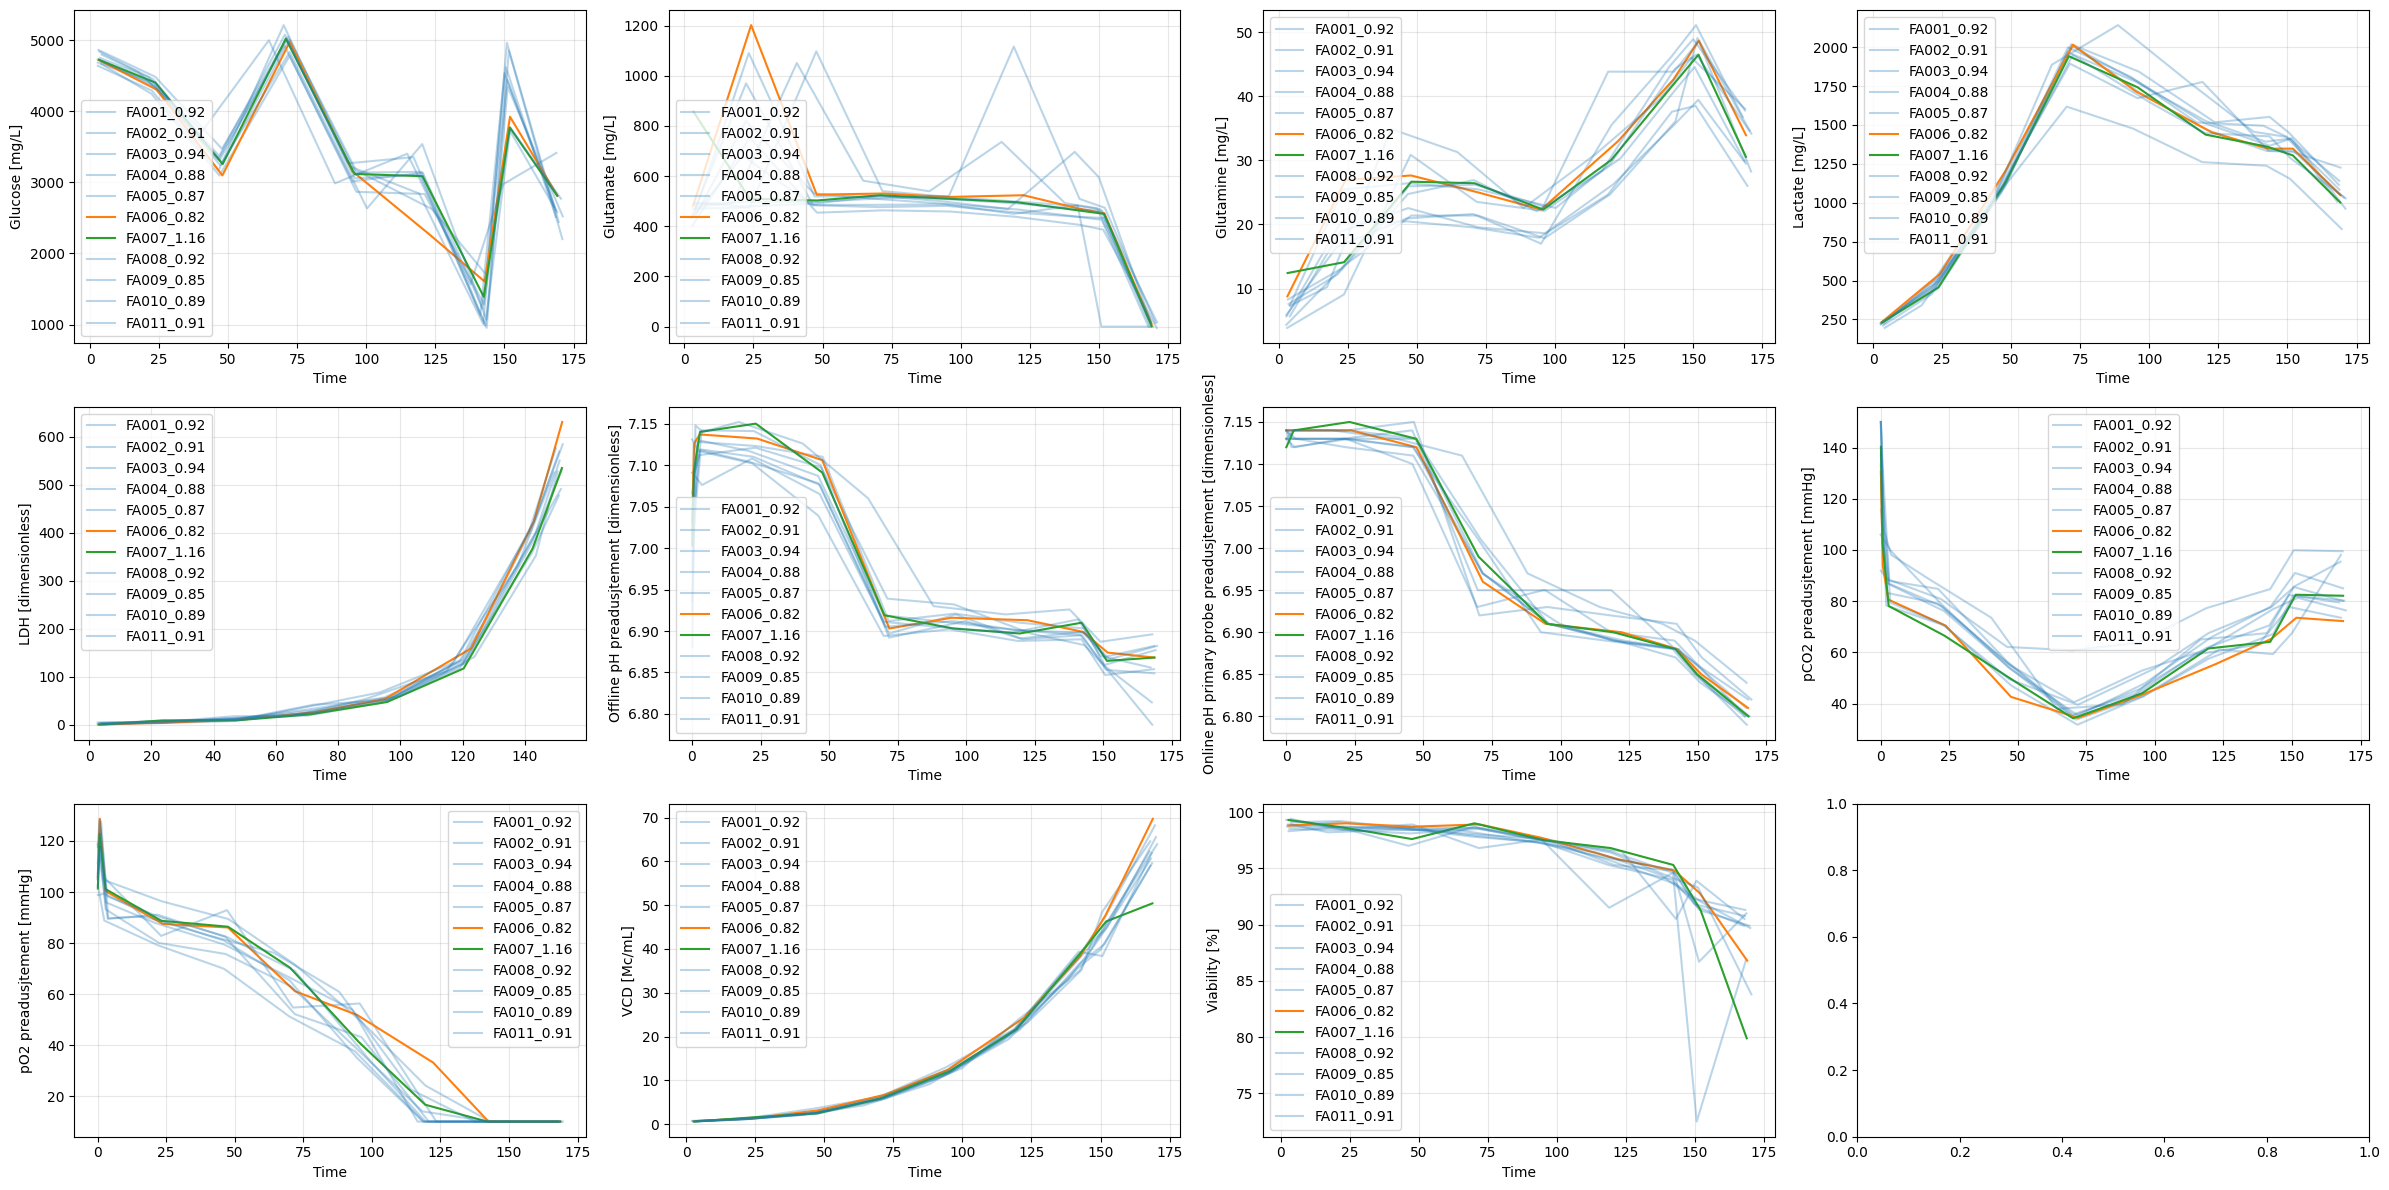

In [84]:
fig, axs = plt.subplots(3, 4, figsize = (24, 12))

batches = [f"FA{str(i).zfill(3)}" for i in range(1, 12)]
colors  = ["C0"] * 5 + ["C1", "C2", "C0", "C0", "C0", "C0"]
alphas  = [0.3] * 5 + [1.0] * 2 + [0.3] * 4

for idx, col in enumerate(df_n1_t.columns[3:]):
    row_idx = idx // 4
    col_idx = idx % 4
    ax = axs[row_idx][col_idx]

    for batch_idx, batch in enumerate(batches):
        sub_df = df_n1_t[df_n1_t["Batch"] == batch].copy()
        sub_df["Process Time [h]"] = sub_df["Process Time [h]"] - sub_df["Process Time [h]"].min()
        sub_df.sort_values(by = "Process Time [h]", inplace = True)
        sub_df = sub_df[~sub_df[col].isna()]
        ax.plot(sub_df["Process Time [h]"], sub_df[col], 
                color = colors[batch_idx], 
                alpha = alphas[batch_idx],
                label = batch + "_" + str(last_df[target_var].loc[batch_idx]))
    ax.legend()
    ax.set_xlabel("Time")
    ax.set_ylabel(col)
    ax.grid(alpha = 0.3)

fig.tight_layout()

In [58]:
n1_last = df_n1_t.groupby("Batch").last().reset_index()
n1_last

,Batch,Process Time [h],Ammonia [mg/L],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001,289.966111,4.464,2577.25,0.48,29.49,1226.17,531.3,6.849,6.80,85.0,10.0,59.60,91.00
1,FA002,312.556667,6.722,2443.71,0.00,26.02,831.26,477.8,6.854,6.79,99.5,10.0,61.93,86.90
2,FA003,264.611111,4.364,2654.60,0.00,36.77,1008.14,569.6,6.814,6.80,95.4,10.0,62.26,89.90
3,FA004,268.328889,4.715,2202.60,-5.25,28.26,962.52,491.2,6.877,6.80,80.2,10.0,68.23,89.90
4,FA005,290.582778,5.417,2512.26,-0.69,29.88,1114.91,528.1,6.787,6.81,98.1,10.0,64.57,90.50
5,FA006,264.123056,6.471,2815.61,10.12,33.92,1049.13,631.2,6.868,6.81,72.2,10.0,69.72,86.80
6,FA007,332.214444,5.417,2811.73,2.07,30.54,1001.86,535.1,6.868,6.80,82.1,10.0,50.41,79.90
7,FA008,280.231389,6.521,2522.68,17.00,34.16,1028.29,550.7,6.882,6.82,80.1,10.0,63.90,83.80
8,FA009,232.294722,6.320,2772.07,15.37,34.65,1033.27,584.6,6.882,6.82,76.4,10.0,65.54,89.70
9,FA010,224.440000,4.163,3415.97,16.54,38.03,1084.51,525.9,6.896,6.84,73.5,10.0,60.63,91.30


In [60]:
for col in n1_last.columns[2:]:
    try:
        results = linregress(n1_last[col].tolist(), last_df[target_var].tolist())
        m, b = results.slope, results.intercept
        rvalue = results.rvalue
        print(rvalue, m)
    except:
        continue

-0.16097292781184033 -0.015017700732122318
0.0701350163892328 2.021583136241288e-05
-0.21009862226487006 -0.0020155195499551824
-0.14531298776411383 -0.003151522712499358
-0.12132581998640232 -0.00010468346678906682
-0.24243663768664453 -0.0004912728282019165
0.018678711586583244 0.05152807391614228
-0.29038968459524744 -1.8287037037036897
0.13239071266559904 0.0012111879529985586
-0.8895065010001147 -0.015083402108068432
-0.6967010989848745 -0.017099886001697658


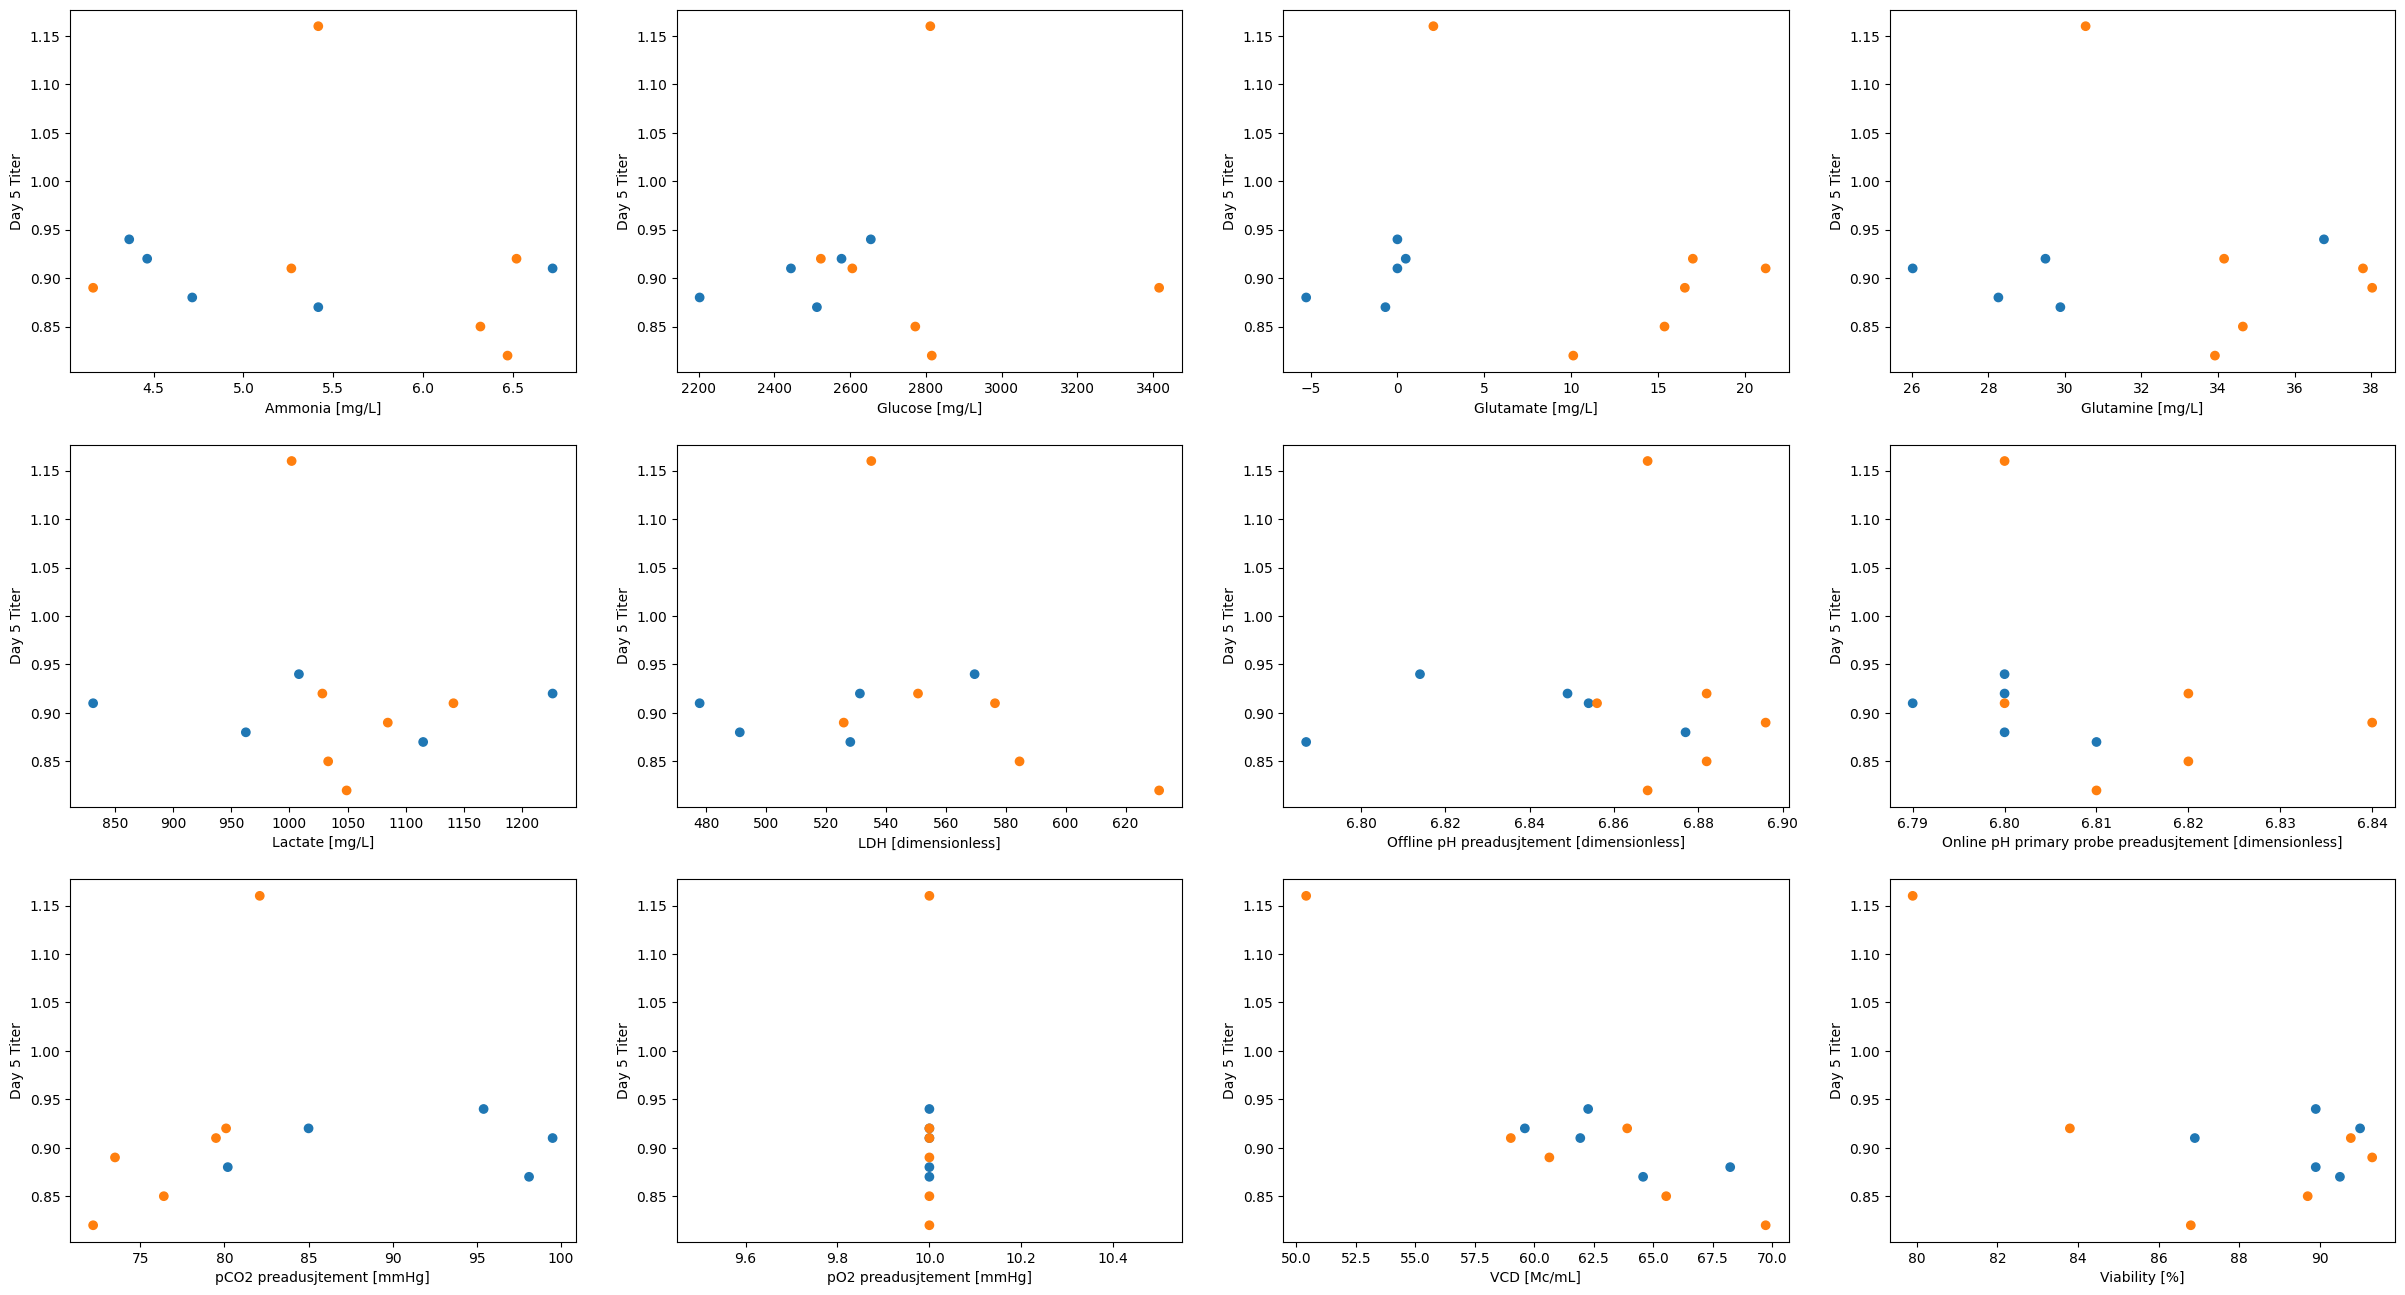

In [70]:
fig, axs = plt.subplots(3, 4, figsize = (30, 16))

for idx, col in enumerate(n1_last.columns[2:]):
    row_idx = idx // 4
    col_idx = idx % 4
    ax = axs[row_idx][col_idx]
    ax.scatter(n1_last[col].tolist(), last_df[target_var].tolist(), c = ["C0"] * 5 + ["C1"] * 6)
    ax.set_xlabel(col)
    ax.set_ylabel("Day 5 Titer")